#  Multimodal Fusion: MS + HS Crop Disease Classification
**Deep Learning Project — Spring 2026**

Architecture:
- **MS Branch**: EfficientNet-B0 + BandAdapter + CBAM (from Model 1) — input `(5, 64, 64)`
- **HS Branch**: SEResNet18 with 125-band input (from Model 2) — input `(125, 32, 32)` → upsampled to 64×64
- **Fusion**: Gated Cross-Modal Attention + MLP Head

Techniques: Label Smoothing, Mixup, Mixed Precision, TTA, 5-Fold CV, Early Stopping

> **Data shape notes:**
> - MS images: `(5, 64, 64)` — 5 multispectral bands, 64×64 spatial
> - HS images: `(32, 32, 125)` — 125 hyperspectral bands, 32×32 spatial
> - HS is bilinearly upsampled to 64×64 inside the Dataset so both branches share the same spatial size


## 1. Install & Imports

In [1]:
!pip install rasterio tifffile timm -q

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from glob import glob
from tqdm.auto import tqdm

import rasterio
import tifffile as tiff

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import timm
import torchvision.models as models

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Seed & Config

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

CFG = {
    # Data
    'ms_bands'       : 5,
    'hs_bands'       : 125,      # all 125 bands used (raw HS shape: 32×32×125)
    'num_classes'    : 3,
    'ms_img_size'    : 64,       # MS native spatial size
    'hs_img_size'    : 32,       # HS native spatial size (upsampled to ms_img_size in Dataset)
    'img_size'       : 64,       # unified spatial size fed to both branches

    # Training
    'batch_size'     : 16,
    'num_epochs'     : 60,
    'lr'             : 3e-4,
    'weight_decay'   : 1e-4,
    'patience'       : 12,
    'seed'           : 42,
    'num_workers'    : 0,

    # Regularization
    'label_smoothing': 0.1,
    'mixup_alpha'    : 0.2,
    'ms_dropout'     : 0.2,
    'hs_dropout'     : 0.3,
    'fusion_dropout' : 0.3,

    # K-Fold
    'n_folds'        : 5,
    'fold_patience'  : 10,
}

LABEL_MAP   = {'Rust': 0, 'Health': 1, 'Other': 2}
CLASS_NAMES = ['Rust', 'Health', 'Other']

print('Config loaded ✓')
print(f'  MS: {CFG["ms_bands"]} bands @ {CFG["ms_img_size"]}×{CFG["ms_img_size"]}')
print(f'  HS: {CFG["hs_bands"]} bands @ {CFG["hs_img_size"]}×{CFG["hs_img_size"]} → upsampled to {CFG["img_size"]}×{CFG["img_size"]}')


Config loaded ✓
  MS: 5 bands @ 64×64
  HS: 125 bands @ 32×32 → upsampled to 64×64


## 3. Mount Drive & Paths

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# ─── Adjust these paths to match your Drive structure ───
BASE_PATH = '/content/drive/MyDrive/DL'
TRAIN_MS  = os.path.join(BASE_PATH, 'TRAIN', 'MS')
TRAIN_HS  = os.path.join(BASE_PATH, 'TRAIN', 'HS')

SAVE_DIR  = '/content/drive/MyDrive/DL/fusion'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'MS dir: {TRAIN_MS}')
print(f'HS dir: {TRAIN_HS}')

Mounted at /content/drive
MS dir: /content/drive/MyDrive/DL/TRAIN/MS
HS dir: /content/drive/MyDrive/DL/TRAIN/HS


## 4. EDA

In [5]:
import os
from collections import Counter

TRAIN_MS = '/content/drive/MyDrive/DL/TRAIN_MS'
TRAIN_HS = '/content/drive/MyDrive/DL/TRAIN_HS'

def get_label(filename):
    """Extract label from filename prefix."""
    for key in LABEL_MAP:
        if filename.startswith(key):
            return LABEL_MAP[key]
    return None

# ── MS files ──────────────────────────────────────────────
ms_files_all  = [f for f in os.listdir(TRAIN_MS) if f.endswith('.tif')]
ms_labels_all = [get_label(f) for f in ms_files_all]
valid_ms      = [(f, l) for f, l in zip(ms_files_all, ms_labels_all) if l is not None]
ms_files_all, ms_labels_all = zip(*valid_ms)

# ── HS files ──────────────────────────────────────────────
hs_files_all  = [f for f in os.listdir(TRAIN_HS) if f.endswith('.tif')]
hs_labels_all = [get_label(f) for f in hs_files_all]
valid_hs      = [(f, l) for f, l in zip(hs_files_all, hs_labels_all) if l is not None]
hs_files_all, hs_labels_all = zip(*valid_hs)

print(f'MS files: {len(ms_files_all)}')
print(f'HS files: {len(hs_files_all)}')
print(f'\nMS class distribution:')
for k, v in Counter(ms_labels_all).items():
    print(f'  {CLASS_NAMES[k]:<10}: {v}  ({v/len(ms_labels_all)*100:.1f}%)')
print(f'\nHS class distribution:')
for k, v in Counter(hs_labels_all).items():
    print(f'  {CLASS_NAMES[k]:<10}: {v}  ({v/len(hs_labels_all)*100:.1f}%)')

MS files: 600
HS files: 600

MS class distribution:
  Health    : 200  (33.3%)
  Other     : 200  (33.3%)
  Rust      : 200  (33.3%)

HS class distribution:
  Health    : 200  (33.3%)
  Other     : 200  (33.3%)
  Rust      : 200  (33.3%)


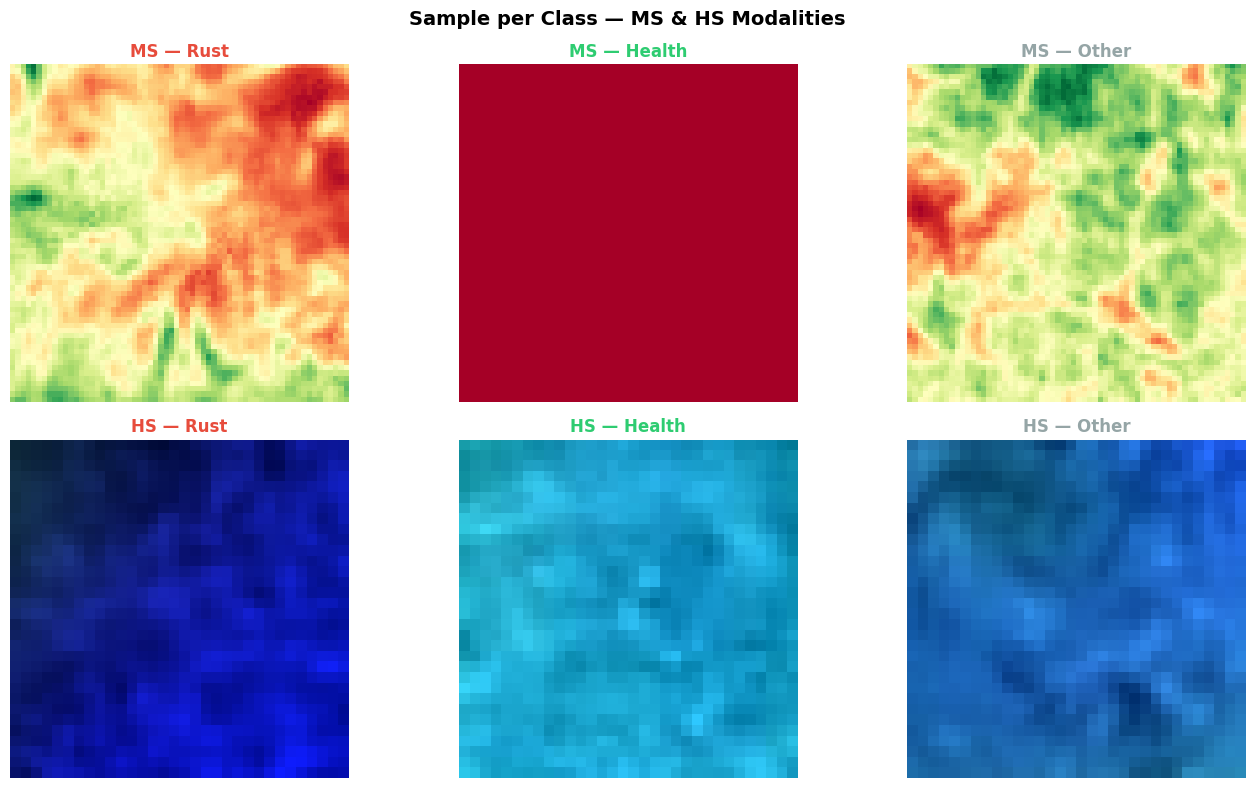

In [6]:
# ── Visualize one sample per class (MS Band 1 + HS Pseudo-RGB) ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
colors = ['#e74c3c', '#2ecc71', '#95a5a6']

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    # MS — band 0
    ms_f = [f for f, l in zip(ms_files_all, ms_labels_all) if l == cls_idx][0]
    with rasterio.open(os.path.join(TRAIN_MS, ms_f)) as src:
        ms_img = src.read().astype(np.float32)
    band = ms_img[0]
    band = (band - band.min()) / (band.max() - band.min() + 1e-8)
    axes[0][cls_idx].imshow(band, cmap='RdYlGn')
    axes[0][cls_idx].set_title(f'MS — {cls_name}', fontweight='bold', color=colors[cls_idx])
    axes[0][cls_idx].axis('off')

    # HS pseudo-RGB — bands [20, 62, 120] (safe for 125-band images)
    hs_f = [f for f, l in zip(hs_files_all, hs_labels_all) if l == cls_idx][0]
    hs_img = tiff.imread(os.path.join(TRAIN_HS, hs_f)).astype(np.float32)  # (32,32,125)
    rgb = hs_img[:, :, [20, 62, 120]]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    axes[1][cls_idx].imshow(rgb)
    axes[1][cls_idx].set_title(f'HS — {cls_name}', fontweight='bold', color=colors[cls_idx])
    axes[1][cls_idx].axis('off')

axes[0][0].set_ylabel('Multispectral (MS) 64×64', fontsize=12)
axes[1][0].set_ylabel('Hyperspectral (HS) 32×32', fontsize=12)
plt.suptitle('Sample per Class — MS & HS Modalities', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Data Splitting

In [7]:
# ── Align MS and HS by stem name ──────────────────────────
# Both modalities should have matching filenames (same crop patch)
ms_stems = {os.path.splitext(f)[0]: f for f in ms_files_all}
hs_stems = {os.path.splitext(f)[0]: f for f in hs_files_all}
common   = sorted(set(ms_stems) & set(hs_stems))

paired_ms     = [ms_stems[s] for s in common]
paired_hs     = [hs_stems[s] for s in common]
paired_labels = [get_label(s.split('_')[0] if '_' in s else s) for s in common]

# fallback: if filenames differ but counts match, pair by sorted order
if len(common) < 10:
    print('⚠ No common stems found — pairing by sorted order (same class assumed)')
    ms_sorted = sorted(ms_files_all)
    hs_sorted = sorted(hs_files_all)
    paired_ms     = ms_sorted
    paired_hs     = hs_sorted
    paired_labels = [get_label(f) for f in ms_sorted]

print(f'Paired samples: {len(paired_ms)}')

# 70 / 15 / 15 split
tv_ms, test_ms, tv_hs, test_hs, tv_l, test_l = train_test_split(
    paired_ms, paired_hs, paired_labels,
    test_size=0.15, random_state=CFG['seed'], stratify=paired_labels
)
train_ms, val_ms, train_hs, val_hs, train_l, val_l = train_test_split(
    tv_ms, tv_hs, tv_l,
    test_size=0.176, random_state=CFG['seed'], stratify=tv_l
)

print(f'Train : {len(train_ms)} | Val : {len(val_ms)} | Test : {len(test_ms)}')
print(f'Train dist: {Counter(train_l)}')
print(f'Val   dist: {Counter(val_l)}')
print(f'Test  dist: {Counter(test_l)}')

Paired samples: 600
Train : 420 | Val : 90 | Test : 90
Train dist: Counter({2: 140, 1: 140, 0: 140})
Val   dist: Counter({1: 30, 2: 30, 0: 30})
Test  dist: Counter({0: 30, 1: 30, 2: 30})


## 6. Per-Band Statistics (MS only, from train)

In [8]:
def compute_ms_stats(data_dir, file_list):

    means = []
    for f in tqdm(file_list, desc='MS mean'):
        with rasterio.open(os.path.join(data_dir, f)) as src:
            img = src.read().astype(np.float32)
        means.append(img.mean(axis=(1, 2)))
    MEAN = np.mean(means, axis=0)

    sq = []
    for f in tqdm(file_list, desc='MS std'):
        with rasterio.open(os.path.join(data_dir, f)) as src:
            img = src.read().astype(np.float32)
        sq.append(((img - MEAN[:, None, None]) ** 2).mean(axis=(1, 2)))
    STD = np.sqrt(np.mean(sq, axis=0))
    return MEAN, STD

MS_MEAN, MS_STD = compute_ms_stats(TRAIN_MS, train_ms)
print('\nMS per-band stats (train):')
for i, (m, s) in enumerate(zip(MS_MEAN, MS_STD)):
    print(f'  B{i+1}: mean={m:.4f}  std={s:.4f}')

MS mean:   0%|          | 0/420 [00:00<?, ?it/s]

MS std:   0%|          | 0/420 [00:00<?, ?it/s]


MS per-band stats (train):
  B1: mean=410.2539  std=369.4442
  B2: mean=758.4592  std=458.5567
  B3: mean=785.3942  std=653.2598
  B4: mean=2208.4758  std=869.5466
  B5: mean=2731.4761  std=1149.6498


## 7. Multimodal Dataset

In [23]:
class MultimodalDataset(Dataset):

    def __init__(self, ms_dir, hs_dir, ms_files, hs_files, labels,
                 ms_mean, ms_std, augment=False, target_size=64):
        self.ms_dir      = ms_dir
        self.hs_dir      = hs_dir
        self.augment     = augment
        self.labels      = labels
        self.target_size = target_size          # unified spatial size (64)
        self.ms_mean     = ms_mean[:, None, None]  # (5,1,1)
        self.ms_std      = ms_std[:, None, None]

        # Load all into RAM
        self.ms_data = []
        self.hs_data = []
        print(f'Loading {len(ms_files)} paired samples into RAM...')
        for mf, hf in tqdm(zip(ms_files, hs_files), total=len(ms_files)):
            with rasterio.open(os.path.join(ms_dir, mf)) as src:
                ms = src.read().astype(np.float32)      # (5, 64, 64)
            hs = tiff.imread(os.path.join(hs_dir, hf)).astype(np.float32)  # (32, 32, 125)
            self.ms_data.append(ms)
            self.hs_data.append(hs)
        print('Dataset loaded ✓')

    def _normalize_ms(self, img):

        return (img - self.ms_mean) / (self.ms_std + 1e-8)

    def _normalize_hs(self, img):

        # Use ALL 125 bands — no band slicing needed
        img = (img - img.mean()) / (img.std() + 1e-6)
        return img

    def _augment_ms(self, ms):

        if np.random.rand() > 0.5:
            ms = np.flip(ms, axis=2).copy()   # horizontal flip
        if np.random.rand() > 0.5:
            ms = np.flip(ms, axis=1).copy()   # vertical flip
        k  = np.random.randint(0, 4)
        ms = np.rot90(ms, k=k, axes=(1, 2)).copy()
        if np.random.rand() > 0.5:            # spectral jitter
            scale = np.random.uniform(0.9, 1.1, (ms.shape[0], 1, 1)).astype(np.float32)
            ms = ms * scale
        if np.random.rand() > 0.7:            # Gaussian noise
            ms = ms + np.random.normal(0, 0.01, ms.shape).astype(np.float32)
        return ms

    def _augment_hs(self, hs, flip_h, flip_v, rot_k):

        if flip_h:
            hs = np.flip(hs, axis=2).copy()
        if flip_v:
            hs = np.flip(hs, axis=1).copy()
        hs = np.rot90(hs, k=rot_k, axes=(1, 2)).copy()
        if np.random.rand() > 0.7:            # band dropout
            b = np.random.randint(0, hs.shape[0])
            hs[b] = 0.0
        return hs

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        ms  = self.ms_data[idx].copy()   # (5, 64, 64)
        #hs  = self.hs_data[idx].copy()# (32, 32, 125)
        hs = self.hs_data[idx].copy()

        if hs.shape[-1] > 125:
          hs = hs[:, :, :125]
        lbl = self.labels[idx]

        #  Normalize
        ms = self._normalize_ms(ms)       # (5, 64, 64)
        hs = self._normalize_hs(hs)       # (32, 32, 125)

        # HS: (32,32,125) → (125, 32, 32)
        hs = hs.transpose(2, 0, 1)        # (125, 32, 32)

        # Augment (after transpose, both channel-first)
        if self.augment:
            flip_h = np.random.rand() > 0.5
            flip_v = np.random.rand() > 0.5
            rot_k  = np.random.randint(0, 4)

            # MS augment (applies its own flip/rot with same params)
            if flip_h:
                ms = np.flip(ms, axis=2).copy()
            if flip_v:
                ms = np.flip(ms, axis=1).copy()
            ms = np.rot90(ms, k=rot_k, axes=(1, 2)).copy()
            if np.random.rand() > 0.5:
                scale = np.random.uniform(0.9, 1.1, (ms.shape[0], 1, 1)).astype(np.float32)
                ms = ms * scale
            if np.random.rand() > 0.7:
                ms = ms + np.random.normal(0, 0.01, ms.shape).astype(np.float32)

            # HS augment — same spatial transform
            hs = self._augment_hs(hs, flip_h, flip_v, rot_k)

        # Convert to tensors
        ms_t = torch.tensor(ms, dtype=torch.float32)   # (5,   64, 64)
        hs_t = torch.tensor(hs, dtype=torch.float32)   # (125, 32, 32)

        hs_t = F.interpolate(
            hs_t.unsqueeze(0),                          # (1, 125, 32, 32)
            size=(self.target_size, self.target_size),  # → (1, 125, 64, 64)
            mode='bilinear',
            align_corners=False
        ).squeeze(0)                                    # (125, 64, 64)

        return ms_t, hs_t, torch.tensor(lbl, dtype=torch.long)


In [24]:
def make_loader(ms_files, hs_files, labels, ms_mean, ms_std,
                augment=False, shuffle=True):
    ds = MultimodalDataset(
        TRAIN_MS, TRAIN_HS,
        ms_files, hs_files, labels,
        ms_mean, ms_std,
        augment=augment,
        target_size=CFG['img_size'],    # both branches → 64×64
    )
    return DataLoader(
        ds,
        batch_size  = CFG['batch_size'],
        shuffle     = shuffle,
        num_workers = CFG['num_workers'],
        pin_memory  = True,
        drop_last   = augment,
    ), ds

train_loader, train_ds = make_loader(train_ms, train_hs, train_l, MS_MEAN, MS_STD, augment=True)
val_loader,   val_ds   = make_loader(val_ms,   val_hs,   val_l,   MS_MEAN, MS_STD, augment=False, shuffle=False)
test_loader,  test_ds  = make_loader(test_ms,  test_hs,  test_l,  MS_MEAN, MS_STD, augment=False, shuffle=False)

print(f'Train: {len(train_ds)} → {len(train_loader)} batches')
print(f'Val  : {len(val_ds)}   → {len(val_loader)} batches')
print(f'Test : {len(test_ds)}  → {len(test_loader)} batches')

#  Quick shape sanity check
ms_s, hs_s, _ = next(iter(train_loader))
print(f'\nBatch shapes — MS: {list(ms_s.shape)}  HS: {list(hs_s.shape)}')
assert ms_s.shape[1] == CFG['ms_bands'],  'MS band count mismatch!'
assert hs_s.shape[1] == CFG['hs_bands'],  'HS band count mismatch!'
assert ms_s.shape[2] == CFG['img_size'],  'MS spatial size mismatch!'
assert hs_s.shape[2] == CFG['img_size'],  'HS spatial size mismatch after upsample!'
print('Shape assertions passed ')


Loading 420 paired samples into RAM...


  0%|          | 0/420 [00:00<?, ?it/s]

Dataset loaded ✓
Loading 90 paired samples into RAM...


  0%|          | 0/90 [00:00<?, ?it/s]

Dataset loaded ✓
Loading 90 paired samples into RAM...


  0%|          | 0/90 [00:00<?, ?it/s]

Dataset loaded ✓
Train: 420 → 26 batches
Val  : 90   → 6 batches
Test : 90  → 6 batches

Batch shapes — MS: [16, 5, 64, 64]  HS: [16, 125, 64, 64]
Shape assertions passed 


## 8. Model Architecture



In [25]:
#  MS Branch components (from Model 1)

class BandAdapter(nn.Module):
    """5 MS bands → 3 channels for EfficientNet."""
    def __init__(self, num_bands=5, mid_channels=16):
        super().__init__()
        self.adapter = nn.Sequential(
            nn.Conv2d(num_bands, mid_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, 3, 1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.adapter(x)


class CBAM(nn.Module):
    """Channel + Spatial Attention (Woo et al., ECCV 2018)."""
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.channel_mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        self.spatial_conv = nn.Conv2d(
            2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def channel_attention(self, x):
        b, c, _, _ = x.shape
        avg = self.channel_mlp(self.avg_pool(x).view(b, c))
        mx  = self.channel_mlp(self.max_pool(x).view(b, c))
        return x * self.sigmoid(avg + mx).view(b, c, 1, 1)

    def spatial_attention(self, x):
        avg_s = x.mean(dim=1, keepdim=True)
        max_s = x.max(dim=1, keepdim=True)[0]
        sa    = self.sigmoid(self.spatial_conv(torch.cat([avg_s, max_s], dim=1)))
        return x * sa

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


class MSBranch(nn.Module):
    """EfficientNet-B0 + CBAM for MS imagery."""
    def __init__(self, num_bands=5, dropout=0.2):
        super().__init__()
        self.band_adapter = BandAdapter(num_bands)
        self.backbone = timm.create_model(
            'efficientnet_b0', pretrained=True,
            num_classes=0, global_pool=''
        )
        self.feat_dim = self.backbone.num_features  # 1280
        self.cbam     = CBAM(self.feat_dim)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.bn       = nn.BatchNorm1d(self.feat_dim)
        self.drop     = nn.Dropout(dropout)

    def forward(self, x):
        x = self.band_adapter(x)
        x = self.backbone(x)
        x = self.cbam(x)
        x = self.pool(x).flatten(1)
        x = self.drop(self.bn(x))
        return x  # (B, 1280)

In [26]:
#  HS Branch components (from Model 2)

class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels
                      // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class HSBranch(nn.Module):

    def __init__(self, in_channels=125, dropout=0.3):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Replace first conv to accept 125 channels (HS raw band count)
        backbone.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=7,
            stride=2, padding=3, bias=False
        )
        self.conv1    = backbone.conv1
        self.bn1      = backbone.bn1
        self.relu     = backbone.relu
        self.maxpool  = backbone.maxpool
        self.se       = SEBlock(64)          # SE attention after first conv
        self.layer1   = backbone.layer1
        self.layer2   = backbone.layer2
        self.layer3   = backbone.layer3
        self.layer4   = backbone.layer4
        self.avgpool  = backbone.avgpool
        self.feat_dim = 512
        self.bn       = nn.BatchNorm1d(self.feat_dim)
        self.drop     = nn.Dropout(dropout)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.se(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.drop(self.bn(x))
        return x  # (B, 512)


In [27]:
#  Gated Cross-Modal Fusion

class GatedFusion(nn.Module):

    def __init__(self, ms_dim=1280, hs_dim=512, fusion_dim=512):
        super().__init__()
        # Project both to same dimension
        self.ms_proj = nn.Linear(ms_dim, fusion_dim, bias=False)
        self.hs_proj = nn.Linear(hs_dim, fusion_dim, bias=False)
        self.ms_bn   = nn.BatchNorm1d(fusion_dim)
        self.hs_bn   = nn.BatchNorm1d(fusion_dim)

        # Gate: takes concatenation, outputs 2 scalars per feature
        self.gate = nn.Sequential(
            nn.Linear(ms_dim + hs_dim, fusion_dim),
            nn.ReLU(inplace=True),
            nn.Linear(fusion_dim, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, ms_feat, hs_feat):
        ms_p = F.relu(self.ms_bn(self.ms_proj(ms_feat)))  # (B, fusion_dim)
        hs_p = F.relu(self.hs_bn(self.hs_proj(hs_feat)))  # (B, fusion_dim)

        # Compute gates
        gates     = self.gate(torch.cat([ms_feat, hs_feat], dim=1))  # (B, 2)
        gate_ms   = gates[:, 0:1]   # (B, 1)
        gate_hs   = gates[:, 1:2]   # (B, 1)

        fused = gate_ms * ms_p + gate_hs * hs_p  # (B, fusion_dim)
        return fused



#  Full Fusion Model

class MultimodalFusionModel(nn.Module):
    """
    Full pipeline:
      MS  → BandAdapter → EfficientNet-B0 → CBAM → ms_feat (1280)
      HS  → SEResNet18 (101ch)            → hs_feat (512)
      Fusion: Gated Cross-Modal → fused (512)
      Head: Concat(ms_feat, hs_feat, fused) → MLP → 3 classes
    """
    def __init__(self, cfg):
        super().__init__()
        self.ms_branch = MSBranch(cfg['ms_bands'], cfg['ms_dropout'])
        self.hs_branch = HSBranch(cfg['hs_bands'], cfg['hs_dropout'])

        ms_dim     = self.ms_branch.feat_dim   # 1280
        hs_dim     = self.hs_branch.feat_dim   # 512
        fusion_dim = 512

        self.fusion = GatedFusion(ms_dim, hs_dim, fusion_dim)

        # Final head: concat all three representations
        head_in = ms_dim + hs_dim + fusion_dim  # 1280+512+512 = 2304
        self.head = nn.Sequential(
            nn.BatchNorm1d(head_in),
            nn.Dropout(cfg['fusion_dropout']),
            nn.Linear(head_in, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(cfg['fusion_dropout'] / 2),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, cfg['num_classes'])
        )

    def forward(self, ms, hs):
        ms_feat = self.ms_branch(ms)              # (B, 1280)
        hs_feat = self.hs_branch(hs)              # (B, 512)
        fused   = self.fusion(ms_feat, hs_feat)   # (B, 512)
        out     = self.head(torch.cat([ms_feat, hs_feat, fused], dim=1))
        return out

In [28]:
#  Sanity check
set_seed(CFG['seed'])
model = MultimodalFusionModel(CFG).to(DEVICE)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('Parameter breakdown:')
print(f'  MS Branch  : {count_params(model.ms_branch):>12,}')
print(f'  HS Branch  : {count_params(model.hs_branch):>12,}')
print(f'  Fusion     : {count_params(model.fusion):>12,}')
print(f'  Head       : {count_params(model.head):>12,}')
print(f'  ─────────────────────────')
print(f'  Total      : {count_params(model):>12,}')

# Both branches receive (B, C, 64, 64) — HS was already upsampled in Dataset
dummy_ms = torch.randn(2, CFG['ms_bands'], CFG['img_size'], CFG['img_size']).to(DEVICE)
dummy_hs = torch.randn(2, CFG['hs_bands'], CFG['img_size'], CFG['img_size']).to(DEVICE)

model.eval()
with torch.no_grad():
    out = model(dummy_ms, dummy_hs)
print(f'\nForward pass:')
print(f'  MS input : {list(dummy_ms.shape)}')
print(f'  HS input : {list(dummy_hs.shape)}  (125 bands @ 64×64 after upsample)')
print(f'  Output   : {list(out.shape)} ✓')
model.train()


Parameter breakdown:
  MS Branch  :    4,215,812
  HS Branch  :   11,560,640
  Fusion     :    1,838,594
  Head       :    1,251,843
  ─────────────────────────
  Total      :   18,866,889

Forward pass:
  MS input : [2, 5, 64, 64]
  HS input : [2, 125, 64, 64]  (125 bands @ 64×64 after upsample)
  Output   : [2, 3] ✓


MultimodalFusionModel(
  (ms_branch): MSBranch(
    (band_adapter): BandAdapter(
      (adapter): Sequential(
        (0): Conv2d(5, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 3, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (4): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (backbone): EfficientNet(
      (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1),

## 9. Training Utilities

In [29]:
# Mixup
def mixup_batch(ms, hs, labels, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(ms.size(0), device=ms.device)
    return (lam * ms + (1-lam) * ms[idx],
            lam * hs + (1-lam) * hs[idx],
            labels, labels[idx], lam)

def mixup_loss(criterion, out, la, lb, lam):
    return lam * criterion(out, la) + (1-lam) * criterion(out, lb)


# Train one epoch
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = correct = total = 0

    for ms, hs, labels in loader:
        ms, hs, labels = ms.to(DEVICE), hs.to(DEVICE), labels.to(DEVICE)
        use_mixup = np.random.rand() > 0.5

        optimizer.zero_grad()
        with autocast():
            if use_mixup:
                ms_m, hs_m, la, lb, lam = mixup_batch(ms, hs, labels, CFG['mixup_alpha'])
                out  = model(ms_m, hs_m)
                loss = mixup_loss(criterion, out, la, lb, lam)
            else:
                out  = model(ms, hs)
                loss = criterion(out, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * ms.size(0)
        if not use_mixup:
            preds    = out.argmax(1)
            correct += (preds == labels).sum().item()
            total   += ms.size(0)

    return total_loss / len(loader.dataset), correct / total if total else 0.0


# Evaluate
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []

    for ms, hs, labels in loader:
        ms, hs, labels = ms.to(DEVICE), hs.to(DEVICE), labels.to(DEVICE)
        with autocast():
            out  = model(ms, hs)
            loss = criterion(out, labels)

        total_loss += loss.item() * ms.size(0)
        preds       = out.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += ms.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


# TTA Evaluate
@torch.no_grad()
def evaluate_tta(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    for ms, hs, labels in loader:
        ms, hs = ms.to(DEVICE), hs.to(DEVICE)
        logits = torch.zeros(ms.size(0), CFG['num_classes']).to(DEVICE)

        tta_transforms = [
            (ms,                              hs),
            (torch.flip(ms, [3]),             torch.flip(hs, [3])),
            (torch.flip(ms, [2]),             torch.flip(hs, [2])),
            (torch.rot90(ms, 1, [2,3]),       torch.rot90(hs, 1, [2,3])),
            (torch.rot90(ms, 3, [2,3]),       torch.rot90(hs, 3, [2,3])),
        ]
        for ms_t, hs_t in tta_transforms:
            with autocast():
                logits += model(ms_t, hs_t).softmax(dim=1)

        logits /= len(tta_transforms)
        preds   = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    return acc, all_preds, all_labels

## 10. 5-Fold Cross Validation Training

In [30]:
# Combine train+val for K-Fold (exclude test)
tv_ms_all  = train_ms + val_ms
tv_hs_all  = train_hs + val_hs
tv_l_all   = train_l  + val_l

skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])

fold_results     = []
best_overall_acc = 0.0
best_history     = None

for fold, (tr_idx, val_idx) in enumerate(skf.split(tv_ms_all, tv_l_all)):

    print(f'\n{"="*65}')
    print(f'  FOLD {fold+1} / {CFG["n_folds"]}')
    print(f'{"="*65}')

    f_ms_tr  = [tv_ms_all[i] for i in tr_idx]
    f_hs_tr  = [tv_hs_all[i] for i in tr_idx]
    f_l_tr   = [tv_l_all[i]  for i in tr_idx]
    f_ms_val = [tv_ms_all[i] for i in val_idx]
    f_hs_val = [tv_hs_all[i] for i in val_idx]
    f_l_val  = [tv_l_all[i]  for i in val_idx]

    # Compute MS stats from fold train only
    f_mean, f_std = compute_ms_stats(TRAIN_MS, f_ms_tr)

    f_train_loader, _ = make_loader(f_ms_tr, f_hs_tr, f_l_tr, f_mean, f_std,
                                    augment=True,  shuffle=True)
    f_val_loader,   _ = make_loader(f_ms_val, f_hs_val, f_l_val, f_mean, f_std,
                                    augment=False, shuffle=False)

    print(f'Train: {len(f_l_tr)} | Val: {len(f_l_val)}')

    # Model, optimizer, scheduler
    set_seed(CFG['seed'] + fold)
    fold_model = MultimodalFusionModel(CFG).to(DEVICE)

    criterion    = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
    optimizer    = torch.optim.AdamW(fold_model.parameters(),
                       lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(
                       optimizer, T_max=CFG['num_epochs'], eta_min=1e-6)
    scaler       = GradScaler()

    best_fold_acc = 0.0
    no_improve    = 0
    history       = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    print(f'\n{"Ep":<5} {"Train Loss":<12} {"Train Acc":<12} {"Val Loss":<12} {"Val Acc":<12} {"LR"}')
    print('─' * 65)

    for epoch in range(1, CFG['num_epochs'] + 1):
        tr_loss, tr_acc = train_one_epoch(fold_model, f_train_loader,
                                          optimizer, criterion, scaler)
        vl_loss, vl_acc, _, _ = evaluate(fold_model, f_val_loader, criterion)

        scheduler.step()
        lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        marker = ''
        if vl_acc > best_fold_acc:
            best_fold_acc = vl_acc
            no_improve    = 0
            marker        = ' ← best'
            torch.save({
                'fold': fold+1, 'epoch': epoch,
                'model_state_dict': fold_model.state_dict(),
                'val_acc': best_fold_acc,
                'ms_mean': f_mean, 'ms_std': f_std,
                'cfg': CFG,
            }, os.path.join(SAVE_DIR, f'fold_{fold+1}_best.pth'))

            if vl_acc > best_overall_acc:
                best_overall_acc = vl_acc
                best_history     = {k: v.copy() for k, v in history.items()}
                torch.save({
                    'fold': fold+1, 'epoch': epoch,
                    'model_state_dict': fold_model.state_dict(),
                    'val_acc': best_overall_acc,
                    'ms_mean': f_mean, 'ms_std': f_std,
                    'cfg': CFG,
                }, os.path.join(SAVE_DIR, 'best_overall.pth'))
        else:
            no_improve += 1

        print(f'{epoch:<5} {tr_loss:<12.4f} {tr_acc:<12.4f} '
              f'{vl_loss:<12.4f} {vl_acc:<12.4f} {lr:.2e}{marker}')

        if no_improve >= CFG['fold_patience']:
            print(f'Early stopping at epoch {epoch}')
            break

    fold_results.append(best_fold_acc)
    print(f'\nFold {fold+1} best val acc: {best_fold_acc:.4f}')

# Summary
print(f'\n{"="*65}')
print(f'K-Fold Summary ({CFG["n_folds"]} folds):')
for i, acc in enumerate(fold_results):
    print(f'  Fold {i+1}: {acc:.4f}')
print(f'\n  Mean : {np.mean(fold_results):.4f}')
print(f'  Std  : {np.std(fold_results):.4f}')
print(f'  Best : {best_overall_acc:.4f}')
print(f'\nBest model → {SAVE_DIR}/best_overall.pth')


  FOLD 1 / 5


MS mean:   0%|          | 0/408 [00:00<?, ?it/s]

MS std:   0%|          | 0/408 [00:00<?, ?it/s]

Loading 408 paired samples into RAM...


  0%|          | 0/408 [00:00<?, ?it/s]

...

Loading 408 paired samples into RAM...


  0%|          | 0/408 [00:00<?, ?it/s]

Dataset loaded ✓
Loading 102 paired samples into RAM...


  0%|          | 0/102 [00:00<?, ?it/s]

Dataset loaded ✓
Train: 408 | Val: 102

Ep    Train Loss   Train Acc    Val Loss     Val Acc      LR
─────────────────────────────────────────────────────────────────
1     1.0464       0.4805       0.9643       0.5784       3.00e-04 ← best
2     0.9262       0.6111       0.8955       0.5980       2.99e-04 ← best
3     0.9460       0.5938       0.8854       0.5980       2.98e-04
4     0.9200       0.5729       0.8650       0.6176       2.97e-04 ← best
5     0.8935       0.6202       0.8955       0.5882       2.95e-04
6     0.8966       0.6477       0.8652       0.6373       2.93e-04 ← best
7     0.8504       0.6534       0.8410       0.6569       2.90e-04 ← best
8     0.8705       0.6298       0.8595       0.6176       2.87e-04
9     0.8443       0.5865       0.8939       0.6275       2.84e-04
10    0.8493       0.6648       0.8884       0.5980       2.80e-04
11    0.8431       0.6354       0.8956       0.5392       2.76e-04
12    0.8274       0.6607       0.8425       0.5980       2.7

## 11. Load Best Model & Evaluate on Test Set

In [31]:
ckpt = torch.load(os.path.join(SAVE_DIR, 'best_overall.pth'),
                  map_location=DEVICE, weights_only=False)

best_model = MultimodalFusionModel(CFG).to(DEVICE)
best_model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded from fold {ckpt["fold"]} epoch {ckpt["epoch"]} — val_acc={ckpt["val_acc"]:.4f}')

# Rebuild test loader with fold stats
f_mean = ckpt['ms_mean']
f_std  = ckpt['ms_std']
test_loader_best, _ = make_loader(test_ms, test_hs, test_l, f_mean, f_std,
                                  augment=False, shuffle=False)

criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])

# Standard evaluation
_, test_acc, test_preds, test_true = evaluate(best_model, test_loader_best, criterion)
print(f'\nTest Accuracy (standard): {test_acc*100:.2f}%')

# TTA evaluation
tta_acc, tta_preds, tta_labels = evaluate_tta(best_model, test_loader_best)
print(f'Test Accuracy (TTA)     : {tta_acc*100:.2f}%')
print(f'TTA improvement         : +{(tta_acc - test_acc)*100:.2f}%')

Loaded from fold 2 epoch 28 — val_acc=0.7157
Loading 90 paired samples into RAM...


  0%|          | 0/90 [00:00<?, ?it/s]

Dataset loaded ✓

Test Accuracy (standard): 62.22%
Test Accuracy (TTA)     : 70.00%
TTA improvement         : +7.78%


## 12. Results & Visualizations

In [32]:
#  Classification Reports
print('Classification Report — Test (Standard):')
print(classification_report(test_true, test_preds,
      target_names=CLASS_NAMES, digits=4))

print('Classification Report — Test + TTA:')
print(classification_report(tta_labels, tta_preds,
      target_names=CLASS_NAMES, digits=4))

Classification Report — Test (Standard):
              precision    recall  f1-score   support

        Rust     0.5946    0.7333    0.6567        30
      Health     0.5000    0.4000    0.4444        30
       Other     0.7586    0.7333    0.7458        30

    accuracy                         0.6222        90
   macro avg     0.6177    0.6222    0.6156        90
weighted avg     0.6177    0.6222    0.6156        90

Classification Report — Test + TTA:
              precision    recall  f1-score   support

        Rust     0.6410    0.8333    0.7246        30
      Health     0.6087    0.4667    0.5283        30
       Other     0.8571    0.8000    0.8276        30

    accuracy                         0.7000        90
   macro avg     0.7023    0.7000    0.6935        90
weighted avg     0.7023    0.7000    0.6935        90



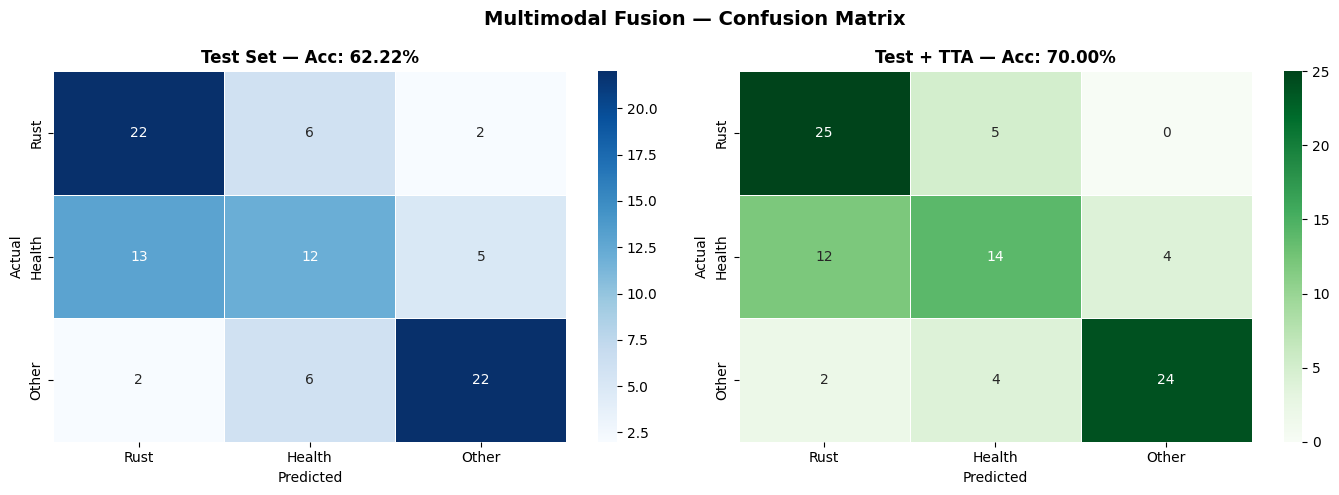

In [33]:
#  Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, true, title, cmap in zip(
    axes,
    [test_preds, tta_preds],
    [test_true,  tta_labels],
    ['Test Set', 'Test + TTA'],
    ['Blues',    'Greens']
):
    cm  = confusion_matrix(true, preds)
    acc = (np.array(preds) == np.array(true)).mean()
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_title(f'{title} — Acc: {acc*100:.2f}%',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Multimodal Fusion — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix_fusion.png'), dpi=150, bbox_inches='tight')
plt.show()

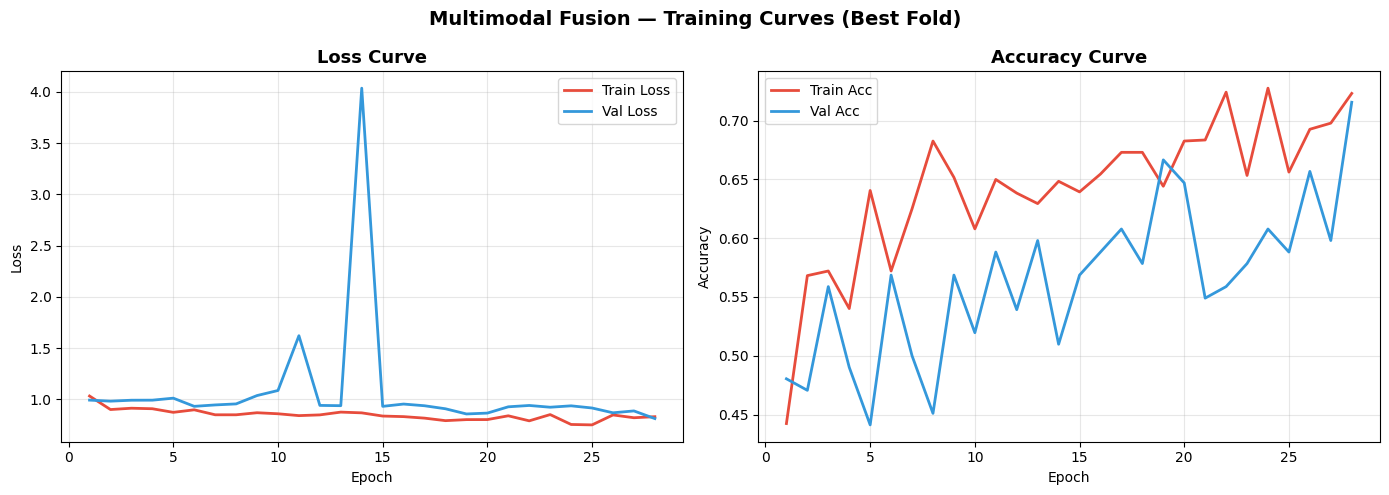

In [34]:
#  Training Curves (best fold)
if best_history:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs    = range(1, len(best_history['train_loss']) + 1)

    axes[0].plot(epochs, best_history['train_loss'], label='Train Loss',
                 color='#e74c3c', linewidth=2)
    axes[0].plot(epochs, best_history['val_loss'],   label='Val Loss',
                 color='#3498db', linewidth=2)
    axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('Loss')
    axes[0].legend();             axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, best_history['train_acc'], label='Train Acc',
                 color='#e74c3c', linewidth=2)
    axes[1].plot(epochs, best_history['val_acc'],   label='Val Acc',
                 color='#3498db', linewidth=2)
    axes[1].set_title('Accuracy Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch');  axes[1].set_ylabel('Accuracy')
    axes[1].legend();             axes[1].grid(True, alpha=0.3)

    plt.suptitle('Multimodal Fusion — Training Curves (Best Fold)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_curves_fusion.png'), dpi=150, bbox_inches='tight')
    plt.show()

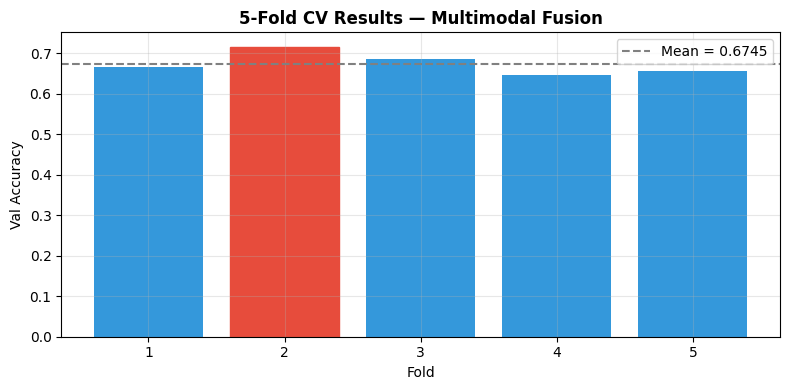


FINAL RESULTS SUMMARY
K-Fold Mean Acc : 67.45% ± 2.43%
Best Fold Acc   : 71.57%
Test Acc        : 62.22%
Test Acc + TTA  : 70.00%


In [35]:
#  K-Fold Summary Bar Chart
plt.figure(figsize=(8, 4))
bars = plt.bar(range(1, CFG['n_folds']+1), fold_results,
               color=['#3498db']*CFG['n_folds'])
bars[fold_results.index(max(fold_results))].set_color('#e74c3c')
plt.axhline(np.mean(fold_results), color='gray', linestyle='--',
            label=f'Mean = {np.mean(fold_results):.4f}')
plt.xlabel('Fold');  plt.ylabel('Val Accuracy')
plt.title('5-Fold CV Results — Multimodal Fusion', fontweight='bold')
plt.xticks(range(1, CFG['n_folds']+1))
plt.legend();  plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'kfold_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*50}')
print(f'FINAL RESULTS SUMMARY')
print(f'{"="*50}')
print(f'K-Fold Mean Acc : {np.mean(fold_results)*100:.2f}% ± {np.std(fold_results)*100:.2f}%')
print(f'Best Fold Acc   : {best_overall_acc*100:.2f}%')
print(f'Test Acc        : {test_acc*100:.2f}%')
print(f'Test Acc + TTA  : {tta_acc*100:.2f}%')